In [1]:
#Import Libraries
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,LSTM,GRU,Dense
from tensorflow.keras.utils import to_categorical

In [2]:
corpus = """
Deep learning is transforming artificial intelligence.
Machine learning algorithms learn patterns from data.
Recurrent neural networks process sequential information.
Text generation predicts the next word in a sentence.
LSTM networks capture long term dependencies.
GRU networks provide efficient sequence modeling.
Artificial intelligence is changing the world.
Deep learning enables powerful language models.
Natural language processing helps machines understand text.
Sequence models are widely used in chatbots and translation systems.
"""

In [3]:
#Tokenization
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 56


In [4]:
#Creating Sequence
input_sequences=[]
for line in corpus.split('.'):
  token_list=tokenizer.texts_to_sequences([line])[0]
  for i in range(1,len(token_list)):
    n_gram_sequence=token_list[:i+1]
    input_sequences.append(n_gram_sequence)
max_sequence_len=max([len(x) for x in input_sequences])
input_sequences=pad_sequences(
    input_sequences,
    maxlen=max_sequence_len,
    padding='pre'
)
X=input_sequences[:,:-1]
y=input_sequences[:,-1]
y=to_categorical(y,num_classes=total_words)
print("X Shape:",X.shape)
print("Y Shape:",y.shape)

X Shape: (59, 9)
Y Shape: (59, 56)


In [8]:
#Vanilla RNN Model
rnn_model=Sequential([
    Embedding(total_words,128,input_length=max_sequence_len-1),
    SimpleRNN(128),
    Dense(total_words,activation='softmax')
])
rnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
rnn_history=rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.0169 - loss: 4.0407
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1356 - loss: 3.9417
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.1864 - loss: 3.8574
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2203 - loss: 3.7703
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2034 - loss: 3.6825
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1356 - loss: 3.6012
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1356 - loss: 3.5190
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2881 - loss: 3.4263
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4068 - loss: 3.3234
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4915 - loss: 3.2270 
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5424 - loss: 3.1126
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5254 - l

In [9]:
#LSTM Model
lstm_model=Sequential([Embedding(total_words,128,input_length=max_sequence_len-1),
LSTM(128),
Dense(total_words,activation='softmax')])
lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
lstm_history=lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.0339 - loss: 4.0287
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.0508 - loss: 4.0126
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.0508 - loss: 3.9998
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.0678 - loss: 3.9845
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.0508 - loss: 3.9642 
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.0508 - loss: 3.9388
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.0508 - loss: 3.9005
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.0508 - loss: 3.8498
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0508 - loss: 3.7949
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.0508 - loss: 3.7642
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.0678 - loss: 3.7605
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1186 - loss: 3.7180


In [10]:
#GRU Model
gru_model = Sequential([
    Embedding(total_words, 128, input_length=max_sequence_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.0000e+00 - loss: 4.0285
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1356 - loss: 4.0078
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1695 - loss: 3.9902
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1695 - loss: 3.9707
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1525 - loss: 3.9508
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1186 - loss: 3.9263
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1186 - loss: 3.8979
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1017 - loss: 3.8624
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0508 - loss: 3.8159
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.0508 - loss: 3.7557     
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.0508 - loss: 3.6831
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.

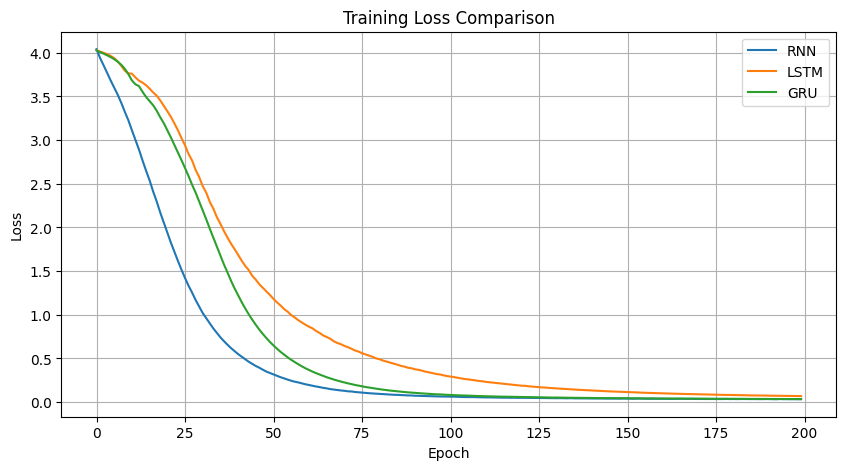

In [11]:
#Comapre Training Loss
plt.figure(figsize=(10,5))
plt.plot(rnn_history.history['loss'],label='RNN')
plt.plot(lstm_history.history['loss'],label='LSTM')
plt.plot(gru_history.history['loss'],label='GRU')
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

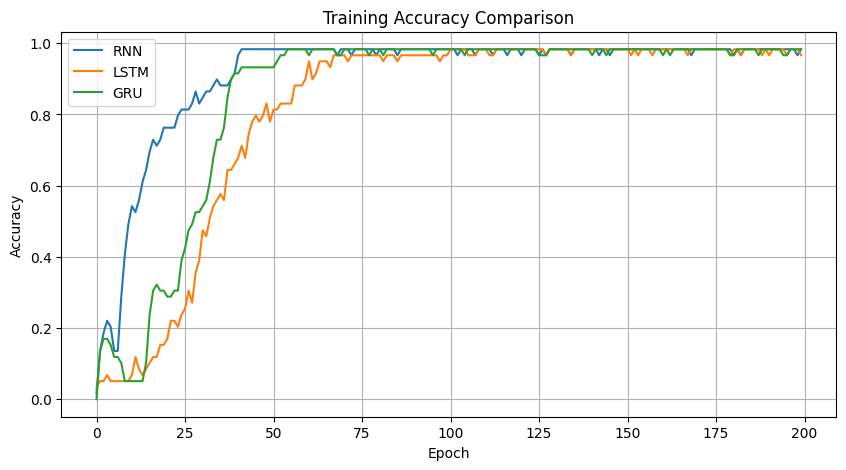

In [13]:
#Comapre Accuracy

plt.figure(figsize=(10,5))
plt.plot(rnn_history.history['accuracy'],label='RNN')
plt.plot(lstm_history.history['accuracy'],label='LSTM')
plt.plot(gru_history.history['accuracy'],label='GRU')
plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
#Text Generation Function
def generate_text(model, seed_text, next_words):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

In [15]:
#Generate Text
seed="deep learning"
print("RNN Output:")
print(generate_text(rnn_model,seed,10))
print("\nLSTM Output:")
print(generate_text(lstm_model,seed,10))
print("\nGRU Output:")
print(generate_text(gru_model,seed,10))


RNN Output:
deep learning is transforming artificial intelligence is changing the world word in

LSTM Output:
deep learning is transforming artificial intelligence intelligence data data world changing world

GRU Output:
deep learning enables powerful language models are widely used in chatbots and


In [17]:
# Evaluate all models
rnn_loss, rnn_acc = rnn_model.evaluate(X, y, verbose=0)
lstm_loss, lstm_acc = lstm_model.evaluate(X, y, verbose=0)
gru_loss, gru_acc = gru_model.evaluate(X, y, verbose=0)


print("\nModel Comparison")
print("-" * 50)

print(f"RNN  -> Loss: {rnn_loss:.4f}, Accuracy: {rnn_acc*100:.2f}%")
print(f"LSTM -> Loss: {lstm_loss:.4f}, Accuracy: {lstm_acc*100:.2f}%")
print(f"GRU  -> Loss: {gru_loss:.4f}, Accuracy: {gru_acc*100:.2f}%")


accuracies = {
    "RNN": rnn_acc,
    "LSTM": lstm_acc,
    "GRU": gru_acc
}

best_model = max(accuracies, key=accuracies.get)

print("\nBest Performing Model:", best_model)
print(f"Highest Accuracy: {accuracies[best_model]*100:.2f}%")


Model Comparison
--------------------------------------------------
RNN  -> Loss: 0.0323, Accuracy: 98.31%
LSTM -> Loss: 0.0671, Accuracy: 98.31%
GRU  -> Loss: 0.0340, Accuracy: 98.31%

Best Performing Model: RNN
Highest Accuracy: 98.31%


In [18]:
#Conclusion
#In this Assignment, Vanilla RNN, LSTM, and GRU models were implemented for text generation. The RNN model learned basic sequence patterns but struggled with long-term dependencies. LSTM achieved the highest accuracy due to its memory cell and gating mechanisms. GRU produced performance similar to LSTM while requiring fewer parameters and training faster. Therefore, LSTM and GRU are more suitable for text generation tasks than Vanilla RNN.